checking what are the distributions of scans in the data after QA 

In [2]:
import statsmodels.formula.api as smf
import pandas as pd          
import matplotlib.pyplot as plt 
import numpy as np

In [3]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')

# combined_df = combined_df[combined_df['tiv'] >= 1000]
combined_df['age_in_years'] = pd.to_numeric(combined_df['age_in_years'], errors='coerce')

combined_df['session_id'] = combined_df['session_id'].astype(str)

# remove 'ses-" "
combined_df['session_id'] = combined_df['session_id'].str.replace(r'^ses-', '', regex=True)

# fill scan_date according to session_id (yyyymmdd) to date format
combined_df['scan_date'] = combined_df['session_id'].apply(
    lambda x: f"{x[:4]}-{x[4:6]}-{x[6:8]}" if len(str(x)) in [8, 12] else None
)
combined_df['scan_year'] = combined_df['scan_date'].apply(lambda x: x.split('-')[0] if x else None)

combined_df['scan_year'] = pd.to_numeric(combined_df['scan_year'], errors='coerce')
 
print(combined_df.columns)

# combined_df.to_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')

Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'unnamed: 0',
       'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path', 'scan_year',
       'classification_label'],
      dtype='object')


In [16]:
# keep only classification_label=1 and snbb
good_scans = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]

# remove duplicates based on session_id and subject_id
good_scans = good_scans.drop_duplicates(subset=['session_id', 'subject_id'])

age_windows = [(20, 24), (25, 29), (30, 34), (35, 39), (40, 44), (45, 49), (50, 54), (55, 59), (60, 64), (65, 100)]



/tmp/ipykernel_41035/3388613694.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


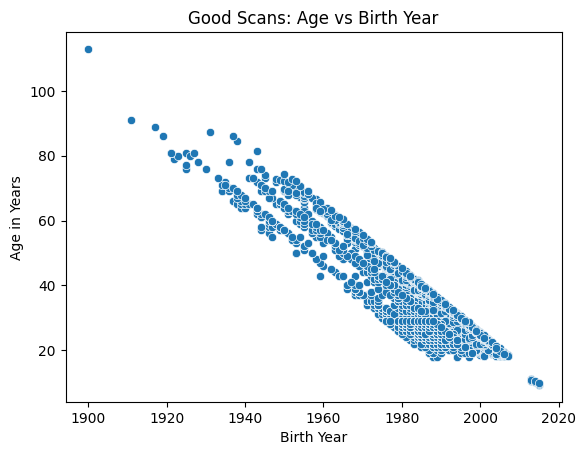

In [17]:
# scatter plot the good scans - y axis is age_in_years, x axis is birth year, color code by amout of subjects

import matplotlib.pyplot as plt
import seaborn as sns
filtered_good = good_scans[(good_scans['age_in_years'] > 20) | (good_scans['birth_year'] != '1900' )]
sns.scatterplot(
    data=filtered_good,
    x='birth_year',
    y='age_in_years',
    palette='viridis'
)
plt.title('Good Scans: Age vs Birth Year')
plt.xlabel('Birth Year')
plt.ylabel('Age in Years')
plt.show()

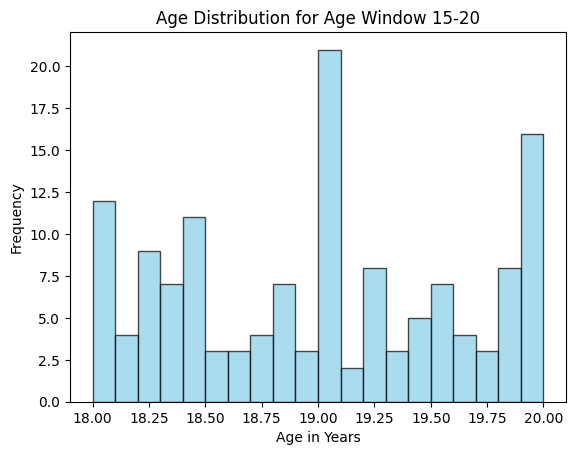

In [18]:
# plot age distribution for age window 15-20
min_age, max_age = 15, 20
filtered_df = good_scans[(good_scans['age_in_years'] >= min_age) & (good_scans['age_in_years'] <= max_age)]
plt.hist(filtered_df['age_in_years'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f'Age Distribution for Age Window {min_age}-{max_age}')
plt.xlabel('Age in Years')
plt.ylabel('Frequency')
plt.show()

Scans in age window 20-24: 726
Number of unique subjects: 726
birth year - age correlation: -0.29527339616631093
birth year range: 1981 to 2005, total 24 years


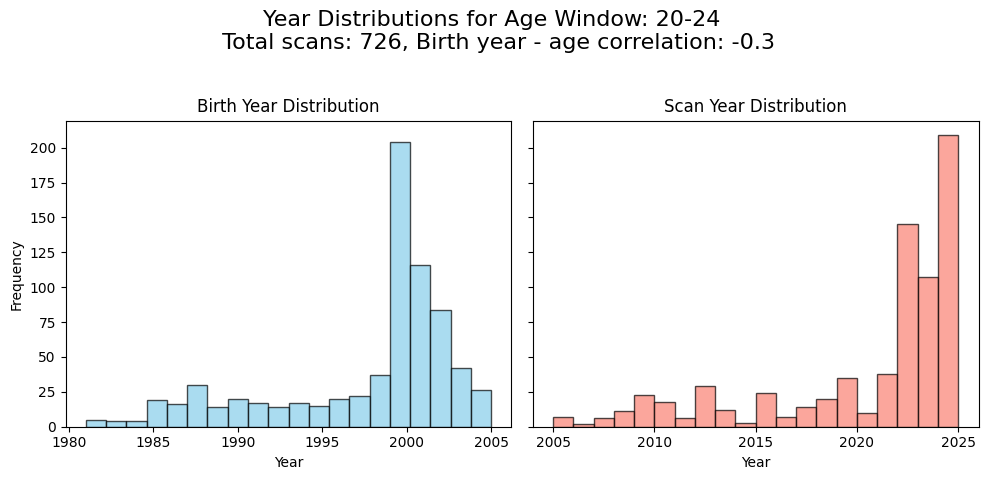

Scans in age window 25-29: 961
Number of unique subjects: 961
birth year - age correlation: -0.28011306055923757
birth year range: 1976 to 2000, total 24 years


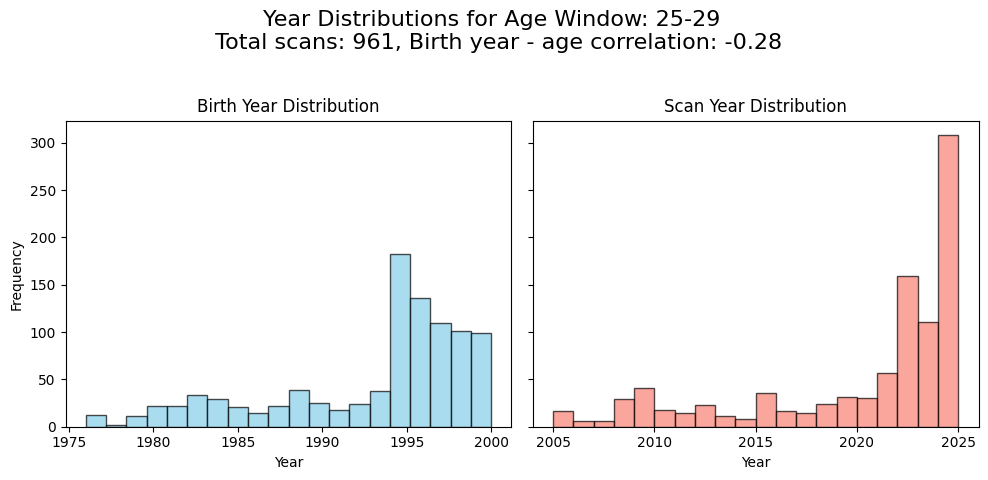

Scans in age window 30-34: 527
Number of unique subjects: 527
birth year - age correlation: -0.11532901632341766
birth year range: 1971 to 1995, total 24 years


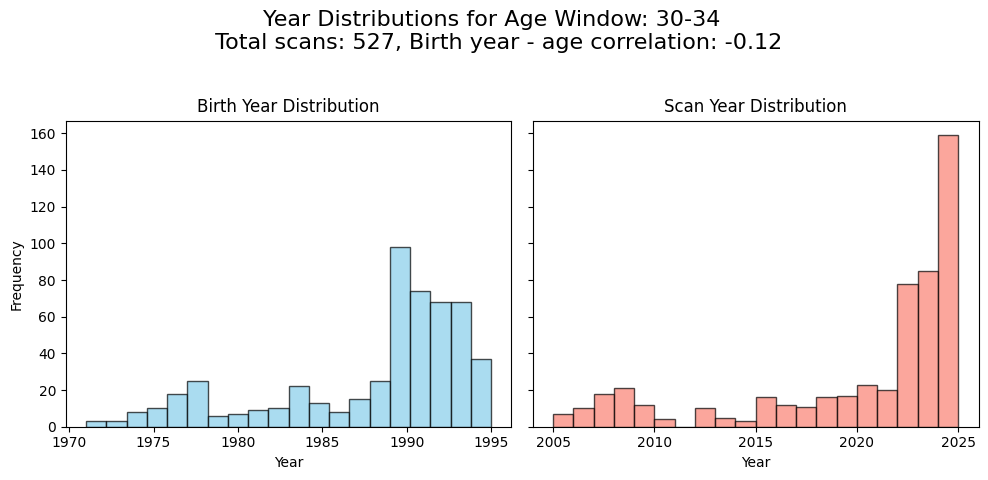

Scans in age window 35-39: 275
Number of unique subjects: 275
birth year - age correlation: -0.14655994554622628
birth year range: 1966 to 1990, total 24 years


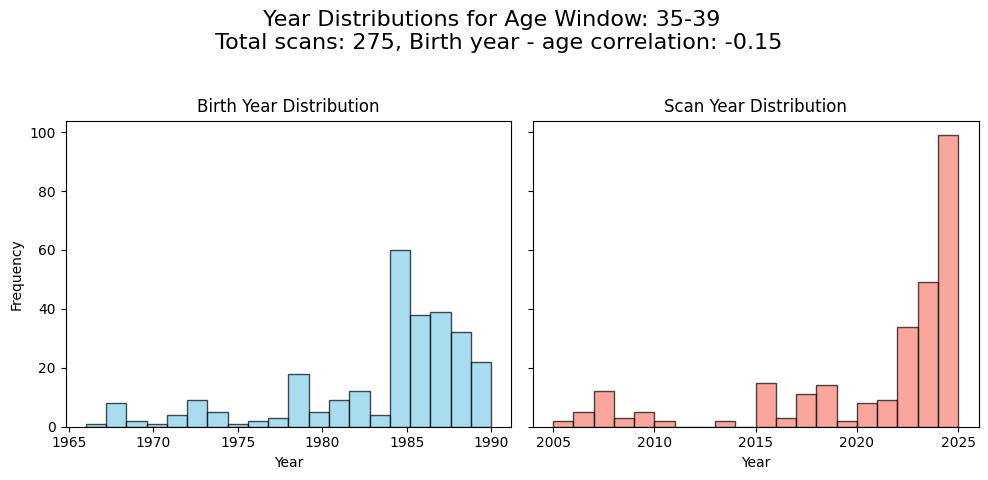

Scans in age window 40-44: 189
Number of unique subjects: 189
birth year - age correlation: -0.24083142891616308
birth year range: 1959 to 1985, total 26 years


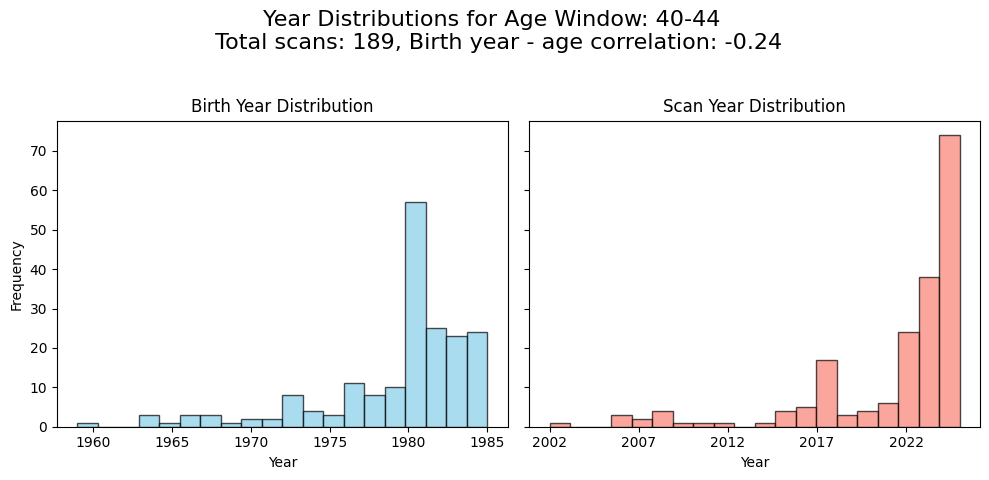

Scans in age window 45-49: 121
Number of unique subjects: 121
birth year - age correlation: -0.2895545691031077
birth year range: 1958 to 1980, total 22 years


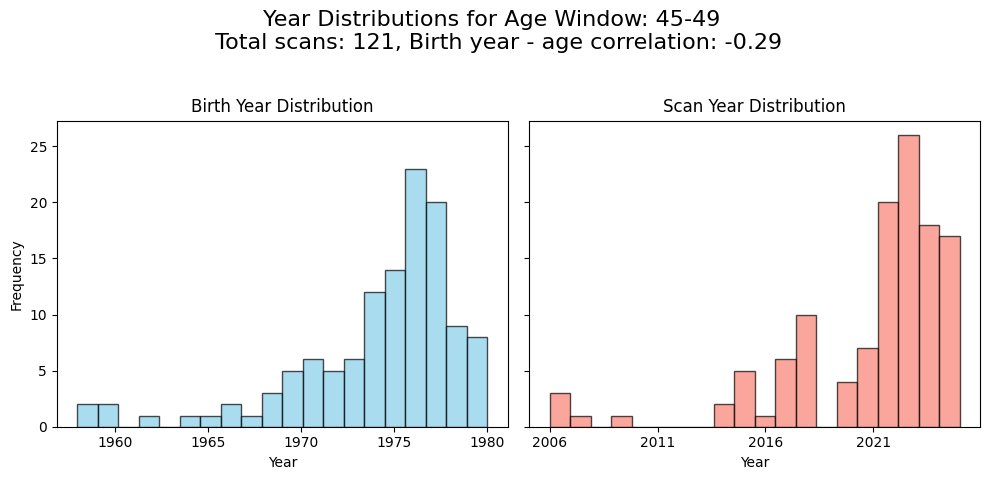

Scans in age window 50-54: 83
Number of unique subjects: 83
birth year - age correlation: -0.17931360913547645
birth year range: 1952 to 1975, total 23 years


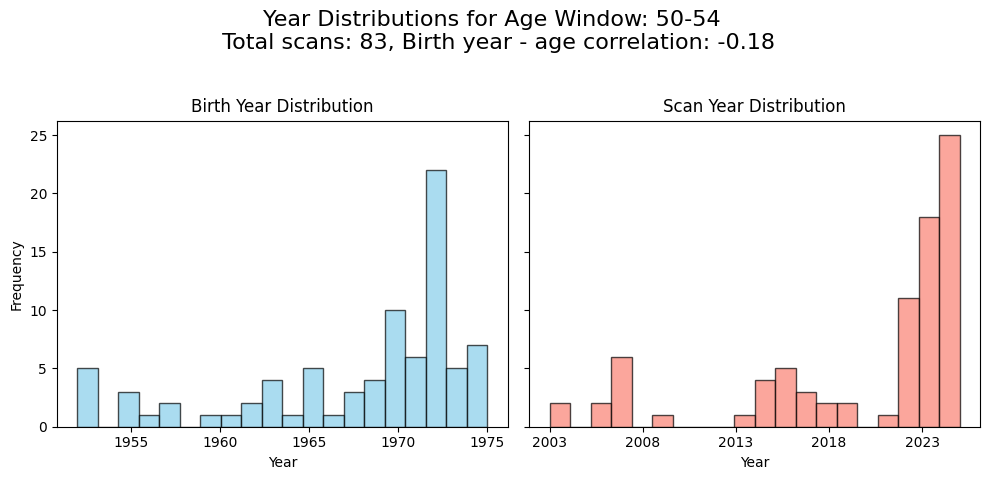

Scans in age window 55-59: 72
Number of unique subjects: 72
birth year - age correlation: -0.24080034052514396
birth year range: 1944 to 1970, total 26 years


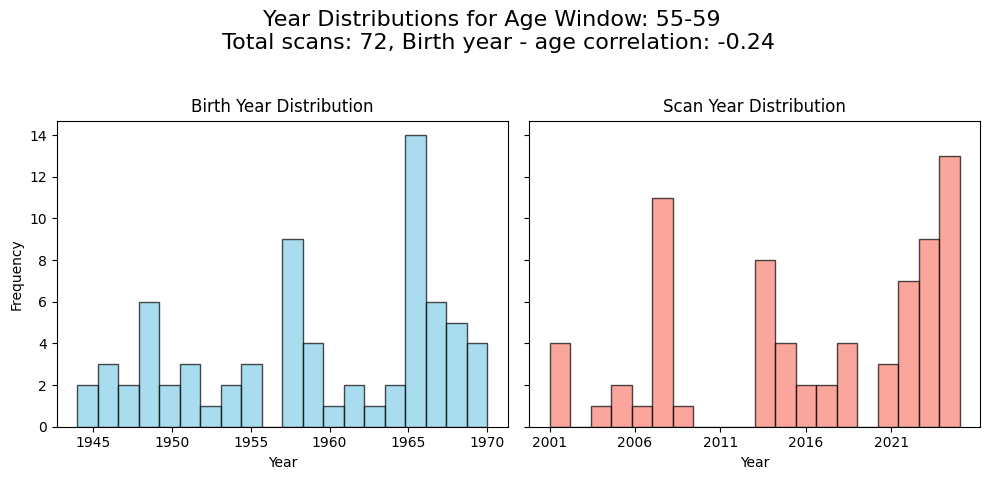

Scans in age window 60-64: 77
Number of unique subjects: 77
birth year - age correlation: -0.10832720924422005
birth year range: 1939 to 1965, total 26 years


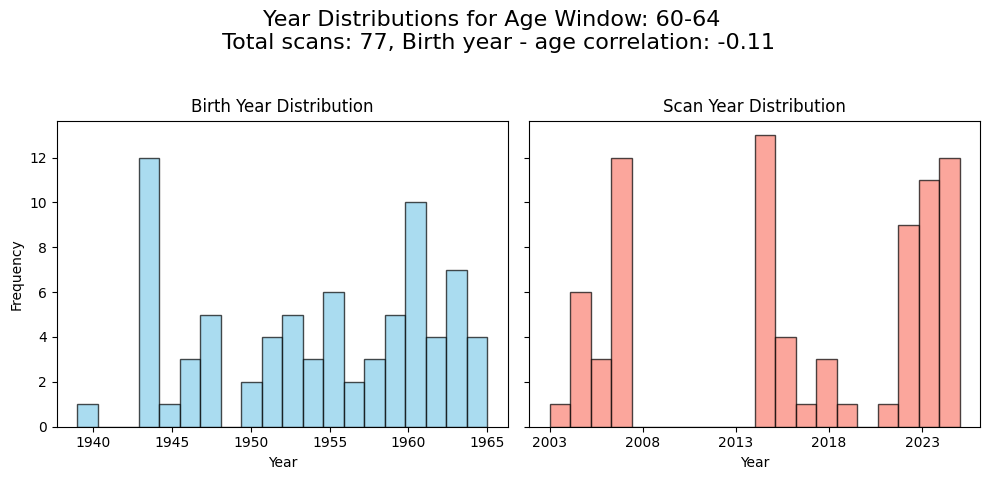

Scans in age window 65-100: 105
Number of unique subjects: 105
birth year - age correlation: -0.669248570710543
birth year range: 1911 to 1959, total 48 years


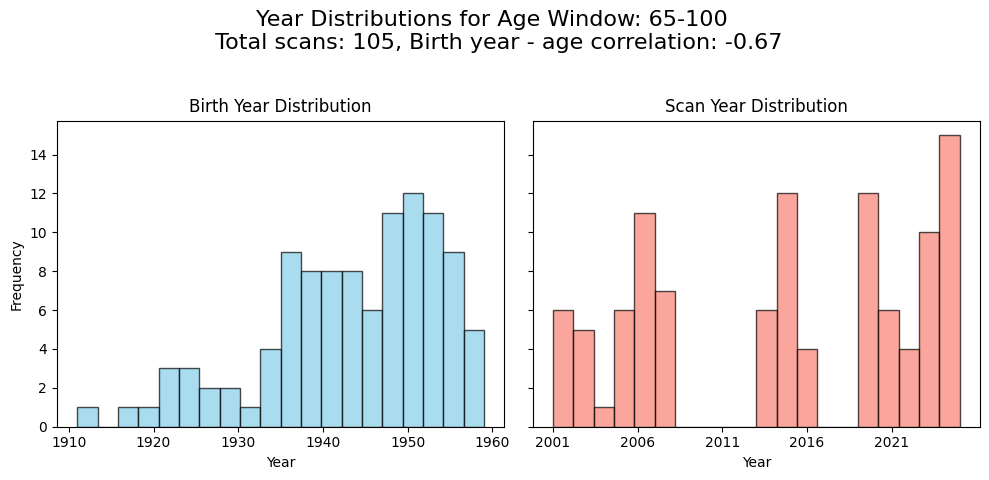

In [31]:
for age_window in age_windows:
    min_age, max_age = age_window
    filtered_df = good_scans[(good_scans['age_in_years'] >= min_age) & (good_scans['age_in_years'] <= max_age)]

    # remove duplicates based on subject_id
    filtered_df = filtered_df.drop_duplicates(subset=['subject_id'], keep='first')

    print(f"Scans in age window {min_age}-{max_age}: {len(filtered_df)}")
    print(f"Number of unique subjects: {filtered_df['subject_id'].nunique()}")
    print(f"birth year - age correlation: {filtered_df['age_in_years'].corr(filtered_df['birth_year'])}")
    print(f"birth year range: {filtered_df['birth_year'].min()} to {filtered_df['birth_year'].max()}, total {filtered_df['birth_year'].max() - filtered_df['birth_year'].min()} years")

    
    
    # Create a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    fig.suptitle(f'Year Distributions for Age Window: {min_age}-{max_age} \n Total scans: {filtered_df["subject_id"].nunique()}, Birth year - age correlation: {filtered_df["age_in_years"].corr(filtered_df["birth_year"]).round(2)}', fontsize=16)
    # make each subplot less wide
    fig.set_size_inches(10, 5)


    # Plot Birth Year in the first subplot
    axes[0].hist(filtered_df['birth_year'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].set_title('Birth Year Distribution')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Frequency')

    # Plot Scan Year in the second subplot
    axes[1].hist(filtered_df['scan_year'], bins=20, color='salmon', edgecolor='black', alpha=0.7)
    axes[1].set_title('Scan Year Distribution')
    axes[1].set_xlabel('Year')
    # xticks are int
    axes[1].set_xticks(range(int(filtered_df['scan_year'].min()), int(filtered_df['scan_year'].max()) + 1, 5))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for the suptitle
    plt.show()